In [1]:
# Cell 1 : Project Title

# ============================================
# TASK 5 - SALES PREDICTION USING PYTHON
# Oasis Infobyte Internship
# ============================================

print("="*60)
print(" SALES PREDICTION USING PYTHON ")
print("="*60)

 SALES PREDICTION USING PYTHON 


In [2]:
# Cell 2 : Import Libraries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# Cell 3 : Load Dataset

df = pd.read_csv(r"C:\Users\bts\OneDrive\OIBSIP\Task 5\Advertising Budget and Sales.csv")

df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [9]:
# Remove unwanted index column
df = df.drop(columns=["Unnamed: 0"])

# Rename columns to simple names
df = df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
})

# Verify the new column names
print(df.columns)

df.head()

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [10]:
# Cell 4 : Dataset Information

print(df.shape)

df.info()

(200, 4)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [11]:
# Cell 5 : Check Missing Values

print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [12]:
# Cell 6 : Descriptive Statistics

df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


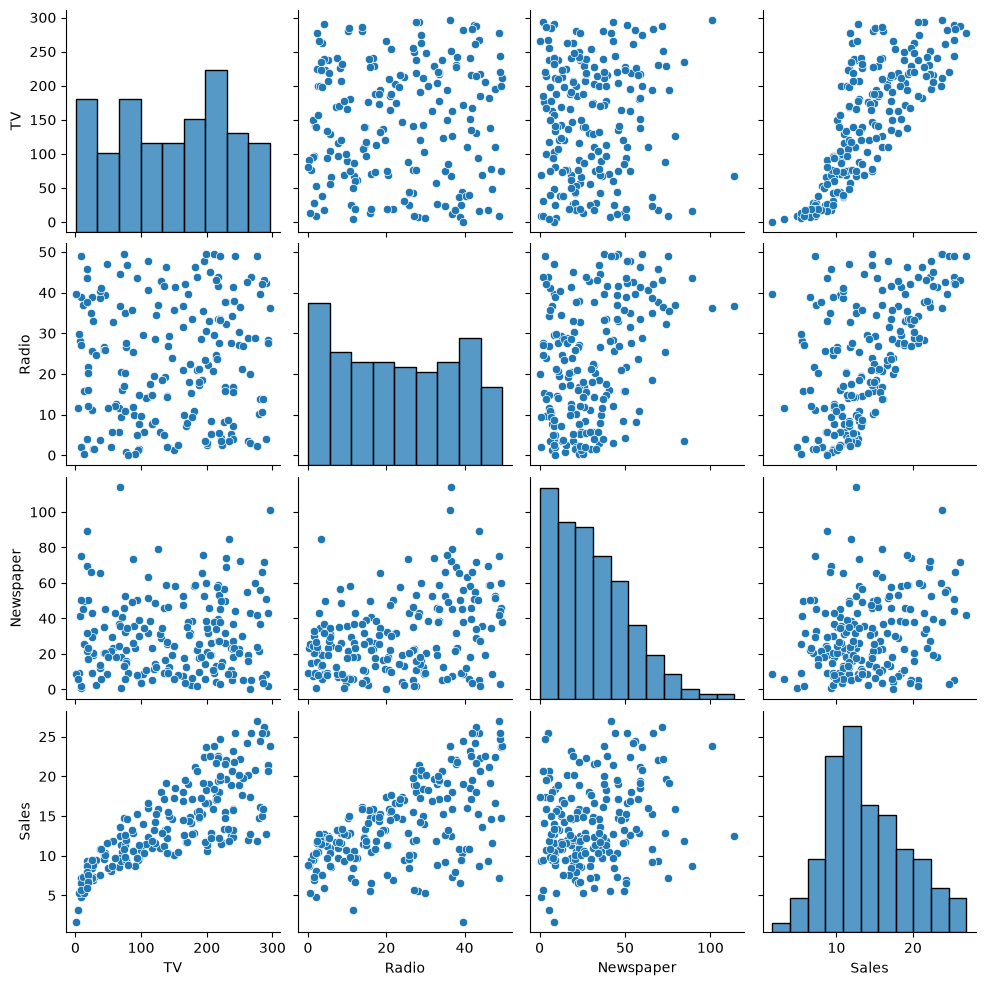

In [13]:
# Cell 7 : Pairplot

sns.pairplot(df)

plt.show()

In [14]:
print(df.columns.tolist())

['TV', 'Radio', 'Newspaper', 'Sales']


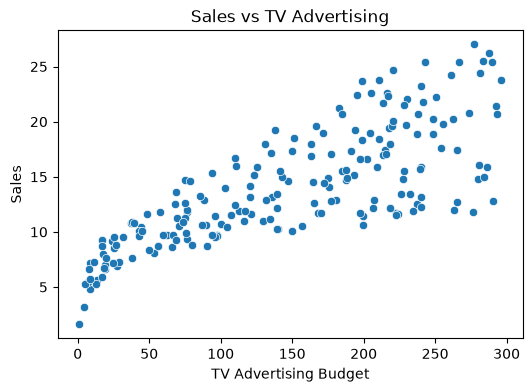

In [16]:
# Cell 8 : Scatter Plot (TV vs Sales)

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="TV",
    y="Sales"
)

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.show()

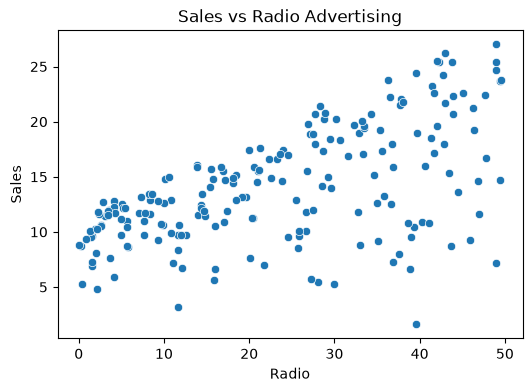

In [17]:
# Cell 9 : Scatter Plot (Radio vs Sales)

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="Radio",
    y="Sales"
)

plt.title("Sales vs Radio Advertising")
plt.show()

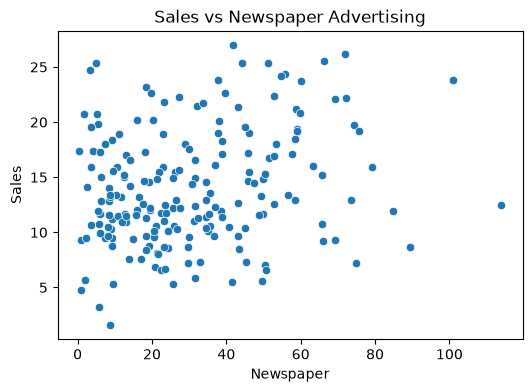

In [18]:
# Cell 10 : Scatter Plot (Newspaper vs Sales)

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="Newspaper",
    y="Sales"
)

plt.title("Sales vs Newspaper Advertising")
plt.show()

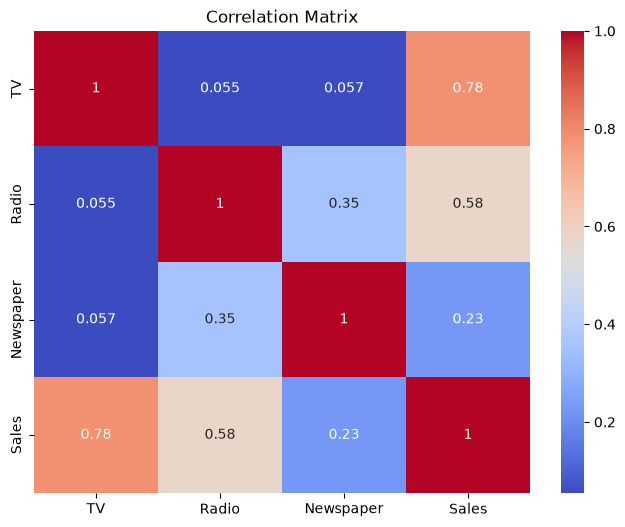

In [19]:
# Cell 11 : Correlation Matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [20]:
# Cell 12 : Feature Selection

X = df[["TV","Radio","Newspaper"]]

y = df["Sales"]

In [21]:
# Cell 13 : Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :",len(X_train))
print("Testing Samples :",len(X_test))

Training Samples : 160
Testing Samples : 40


In [22]:
# Cell 14 : Linear Regression Model

lr = LinearRegression()

lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
# Cell 15 : Predictions

lr_pred = lr.predict(X_test)

In [24]:
# Cell 16 : Evaluation

mae = mean_absolute_error(y_test,lr_pred)

rmse = np.sqrt(mean_squared_error(y_test,lr_pred))

r2 = r2_score(y_test,lr_pred)

print("Linear Regression Results")

print("MAE :",round(mae,3))
print("RMSE :",round(rmse,3))
print("R2 Score :",round(r2,3))

Linear Regression Results
MAE : 1.461
RMSE : 1.782
R2 Score : 0.899


In [25]:
# Cell 17 : Random Forest Model

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
# Cell 18 : Random Forest Prediction

rf_pred = rf.predict(X_test)

In [27]:
# Cell 19 : Random Forest Evaluation

rf_mae = mean_absolute_error(y_test,rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))

rf_r2 = r2_score(y_test,rf_pred)

print("Random Forest Results")

print("MAE :",round(rf_mae,3))
print("RMSE :",round(rf_rmse,3))
print("R2 Score :",round(rf_r2,3))

Random Forest Results
MAE : 0.629
RMSE : 0.757
R2 Score : 0.982


In [28]:
# Cell 20 : Compare Models

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        mae,
        rf_mae
    ],

    "RMSE":[
        rmse,
        rf_rmse
    ],

    "R2 Score":[
        r2,
        rf_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628713,0.757235,0.981833


In [29]:
# Cell 21 : Best Model

best_model = rf

predictions = rf_pred

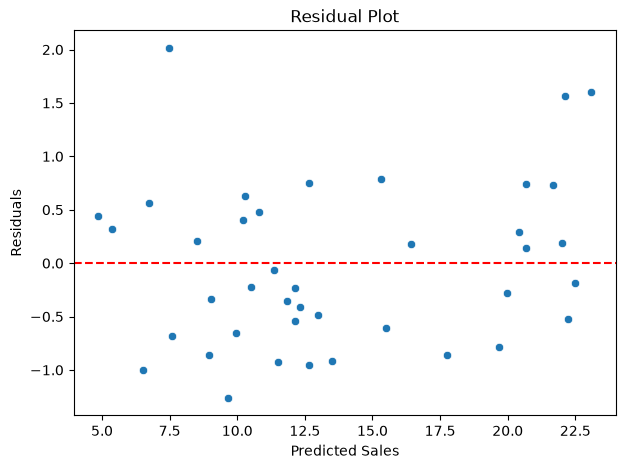

In [30]:
# Cell 22 : Residual Plot

residuals = y_test - predictions

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [31]:
# Cell 23 : Feature Importance

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,TV,0.624727
1,Radio,0.362119
2,Newspaper,0.013153


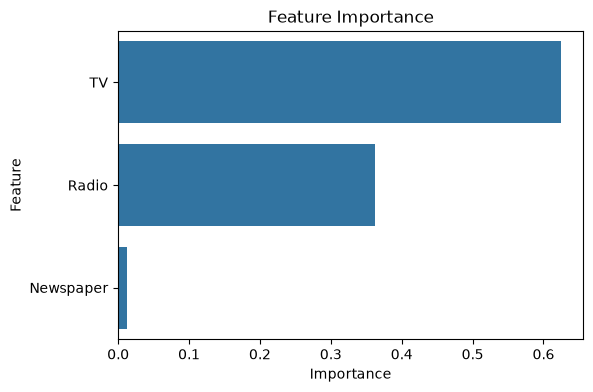

In [32]:
# Cell 24 : Feature Importance Plot

plt.figure(figsize=(6,4))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [33]:
# Cell 25 : Linear Regression Coefficients

coef = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":lr.coef_

})

coef

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [34]:
# Cell 26 : Final Interpretation

print("="*60)
print("PROJECT CONCLUSION")
print("="*60)

highest = coef.iloc[
    coef["Coefficient"].abs().argmax()
]

print("Highest Impact Advertising Channel :")

print(highest["Feature"])

print()

print("Coefficient :",highest["Coefficient"])

print()

print("The channel with the largest coefficient contributes the")
print("most towards increasing product sales.")

PROJECT CONCLUSION
Highest Impact Advertising Channel :
Radio

Coefficient : 0.1891950542343766

The channel with the largest coefficient contributes the
most towards increasing product sales.


In [35]:
# Cell 27 : Congratulations

print("="*60)

print("🎉 Congratulations!")

print()

print("Task 5 - Sales Prediction Using Python Completed Successfully!")

print()

print("Skills Demonstrated")

print("✔ Data Cleaning")
print("✔ Exploratory Data Analysis")
print("✔ Data Visualization")
print("✔ Correlation Analysis")
print("✔ Linear Regression")
print("✔ Random Forest Regression")
print("✔ Model Evaluation")
print("✔ Feature Importance")
print("✔ Residual Analysis")

print("="*60)

🎉 Congratulations!

Task 5 - Sales Prediction Using Python Completed Successfully!

Skills Demonstrated
✔ Data Cleaning
✔ Exploratory Data Analysis
✔ Data Visualization
✔ Correlation Analysis
✔ Linear Regression
✔ Random Forest Regression
✔ Model Evaluation
✔ Feature Importance
✔ Residual Analysis
